# 📊 Module 9 · Descriptive Statistics
### Course: Python from Scratch for Data Analysis

**Prerequisites:** Modules 1–8

---

### What you will learn today

1. **Central tendency:** mean, median, mode — when each is right
2. **Dispersion:** variance, standard deviation, IQR, range
3. **Comparing groups** with groupby and visualizations
4. **Reading and interpreting** boxplots and histograms

## Dataset for this module

We will use a synthetic dataset of 20 university students across three programs.
Run this cell first — all exercises depend on it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Students across 3 university programs.
students = pd.DataFrame({
    "name": ["Valentina","Santiago","Camila","Andrés","Isabella","Daniel","Sofía",
             "Miguel","Mariana","Julián","Laura","Carlos","Ana","Felipe","Paola",
             "Esteban","Natalia","Ricardo","Alejandra","Sebastián"],
    "program": ["Engineering","Business","Engineering","Medicine","Business",
                "Engineering","Medicine","Business","Engineering","Medicine",
                "Engineering","Business","Medicine","Engineering","Business",
                "Medicine","Engineering","Business","Medicine","Engineering"],
    "gpa": [4.2,3.1,4.8,2.9,3.7,4.5,3.3,2.8,4.1,3.6,
            3.9,2.5,4.0,3.8,3.2,2.7,4.4,3.0,3.5,4.6],
    "age": [20,22,19,21,23,20,22,24,19,21,20,23,22,21,20,23,19,22,21,20],
    "semester": [4,6,2,5,8,3,6,9,2,5,4,8,7,5,4,8,2,6,7,3],
    "study_hours_per_week": [25,15,30,18,20,28,16,12,32,19,24,14,22,27,17,15,31,16,21,29]
})

print("Dataset loaded successfully.")
print(f"Shape: {students.shape}")
students.head()

Dataset loaded successfully.
Shape: (20, 6)


,name,program,gpa,age,semester,study_hours_per_week
0,Valentina,Engineering,4.2,20,4,25
1,Santiago,Business,3.1,22,6,15
2,Camila,Engineering,4.8,19,2,30
3,Andrés,Medicine,2.9,21,5,18
4,Isabella,Business,3.7,23,8,20


---

## 🔷 Block 1 — Central Tendency

### Analogy: the misleading average

Imagine 10 students comparing their monthly allowances.
Nine students receive **500,000 COP** each.
One student — whose parents are wealthy — receives **10,000,000 COP**.

| Measure | Value | Representative? |
|---------|-------|----------------|
| Mean | 1,450,000 COP | ❌ Represents nobody |
| Median | 500,000 COP | ✅ Represents the typical student |
| Mode | 500,000 COP | ✅ Most common value |

**Choosing the right measure matters.** The mean is pulled up by that one outlier and gives a false picture of "typical".

---

### The three measures of central tendency

| Measure | Formula | Best when |
|---------|---------|----------|
| **Mean** | sum ÷ count | No extreme outliers; symmetric data |
| **Median** | middle value when sorted | Outliers present; skewed data |
| **Mode** | most frequent value | Categorical or discrete data |

### 1.1 — Mean

The mean is the arithmetic average: add everything up, divide by how many there are.

> **Before running:** What do you expect the average GPA to be? Look at the dataset and make a quick guess.

In [2]:
# Compute the mean GPA for all students.
mean_gpa = students["gpa"].mean()
print(f"Mean GPA: {mean_gpa:.2f}")

# Compute the mean GPA per program.
mean_by_program = students.groupby("program")["gpa"].mean()
print("\nMean GPA by program:")
print(mean_by_program)

Mean GPA: 3.63

Mean GPA by program:
program
Business       3.050000
Engineering    4.287500
Medicine       3.333333
Name: gpa, dtype: float64


### 1.2 — Median

The median is the **middle value** when all values are sorted.
If there is an even number of values, take the average of the two middle values.

- With 20 students, the median is the average of the 10th and 11th values when sorted.
- It does **not** care how extreme the highest or lowest values are — only which value sits in the middle.

In [3]:
# Compute the median GPA.
median_gpa = students["gpa"].median()
print(f"Median GPA: {median_gpa:.2f}")

# Median per program.
median_by_program = students.groupby("program")["gpa"].median()
print("\nMedian GPA by program:")
print(median_by_program)

# Compare mean vs median — if they are close, the data is roughly symmetric.
print(f"\nAll students — mean: {mean_gpa:.2f}, median: {median_gpa:.2f}")
print("Difference:", round(mean_gpa - median_gpa, 2))

Median GPA: 3.65

Median GPA by program:
program
Business       3.05
Engineering    4.30
Medicine       3.40
Name: gpa, dtype: float64

All students — mean: 3.63, median: 3.65
Difference: -0.02


### 1.3 — Mode

The mode is the **most frequently occurring value**.
Pandas returns a Series (not a single number) because there can be multiple modes.
Use `[0]` to get the first one.

In [4]:
# Mode returns a Series — there could be more than one most-common value.
mode_result = students["gpa"].mode()
print("Mode result (full Series):", mode_result.values)
print(f"First mode: {mode_result[0]}")

# For categorical columns, mode is very useful.
most_common_program = students["program"].mode()[0]
print(f"\nMost common program: {most_common_program}")

# How many students are in each program?
print("\nStudents per program:")
print(students["program"].value_counts())

Mode result (full Series): [2.5 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.5 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.4 4.5
 4.6 4.8]
First mode: 2.5

Most common program: Engineering

Students per program:
program
Engineering    8
Business       6
Medicine       6
Name: count, dtype: int64


### 1.4 — Why the median is robust: the outlier demo

Let's see the mean vs median in action with salaries — a classic example where outliers cause problems.

> **Before running:** If we add a CEO earning 50,000,000 COP to a team where everyone earns around 2–3 million, what do you think happens to the mean? And the median?

In [5]:
# A small team's salaries in COP.
salaries = np.array([2000000, 2500000, 2800000, 3000000, 3200000])
print("=== Without the CEO ===")
print(f"Mean:   {salaries.mean():>12,.0f} COP")
print(f"Median: {np.median(salaries):>12,.0f} COP")

# Now add one CEO salary.
salaries_with_ceo = np.append(salaries, 50000000)
print("\n=== With the CEO ===")
print(f"Mean:   {salaries_with_ceo.mean():>12,.0f} COP  ← pulled way up")
print(f"Median: {np.median(salaries_with_ceo):>12,.0f} COP  ← barely changes")
print("\nKey lesson: the mean is sensitive to outliers. The median is robust.")

=== Without the CEO ===
Mean:      2,700,000 COP
Median:    2,800,000 COP

=== With the CEO ===
Mean:     10,583,333 COP  ← pulled way up
Median:    2,900,000 COP  ← barely changes

Key lesson: the mean is sensitive to outliers. The median is robust.


### 1.5 — `.describe()`: all summary stats at once

`.describe()` gives you a quick overview of all numerical columns at once.
Let's read it carefully — every row has a name you now know:

In [6]:
# Full summary statistics for the students dataset.
students.describe()

,gpa,age,semester,study_hours_per_week
count,20.000000,20.00000,20.00000,20.000000
mean,3.630000,21.10000,5.20000,21.550000
std,0.680634,1.48324,2.19089,6.295153
min,2.500000,19.00000,2.00000,12.000000
25%,3.075000,20.00000,3.75000,16.000000
50%,3.650000,21.00000,5.00000,20.500000
75%,4.125000,22.00000,7.00000,27.250000
max,4.800000,24.00000,9.00000,32.000000


**Reading `.describe()` output:**

| Row | What it means |
|-----|---------------|
| `count` | How many non-null values |
| `mean` | Arithmetic average |
| `std` | Standard deviation (spread — we cover this in Block 2) |
| `min` | Smallest value |
| `25%` | First quartile (Q1): 25% of values are below this |
| `50%` | Median (Q2): 50% are below, 50% above |
| `75%` | Third quartile (Q3): 75% of values are below this |
| `max` | Largest value |

### Exercise 1 — Central tendency by program

**Pattern: Accumulator → summary statistics**

---

**Before you code**

- **Inputs:** the `students` DataFrame, column `gpa`, column `program`
- **Output:** a table showing mean, median, and mode of GPA for each program

**Decomposed steps:**

1. For each program, filter the students belonging to that program.
2. Take the GPA values of those students.
3. Compute: mean, median, and mode of those GPA values.
4. Print the three numbers next to the program name.
5. Compare mean vs median: if they are close, the data is symmetric; if they differ, outliers may be present.

**Pattern:** Accumulator — we are computing summary numbers for each group.

---

In [7]:
# Exercise 1: mean, median, and mode of GPA for each program.

programs = students["program"].unique()

print(f"{'Program':<15} {'Mean':>6} {'Median':>8} {'Mode':>6}")
print("-" * 38)

for prog in sorted(programs):
    # Step 1: filter students in this program.
    subset = students[students["program"] == prog]["gpa"]
    # Step 2: compute the three measures.
    m_mean   = subset.mean()
    m_median = subset.median()
    m_mode   = subset.mode()[0]
    # Step 3: print a formatted row.
    print(f"{prog:<15} {m_mean:>6.2f} {m_median:>8.2f} {m_mode:>6.1f}")

# Round 1: prog = 'Business'   → computes stats for Business students
# Round 2: prog = 'Engineering' → computes stats for Engineering students
# Round 3: prog = 'Medicine'   → computes stats for Medicine students

print("\nObservation: compare mean vs median for each program.")
print("If they are close → data is roughly symmetric for that program.")
print("If mean > median → a few high GPAs are pulling the average up.")

Program           Mean   Median   Mode
--------------------------------------
Business          3.05     3.05    2.5
Engineering       4.29     4.30    3.8
Medicine          3.33     3.40    2.7

Observation: compare mean vs median for each program.
If they are close → data is roughly symmetric for that program.
If mean > median → a few high GPAs are pulling the average up.


---

## 🔷 Block 2 — Dispersion

### Analogy: same average, different reality

Two classes can have the **exact same average GPA** but completely different student profiles:

- **Class A:** Every student has a GPA between 3.0 and 4.0. Very homogeneous.
- **Class B:** Half of the students are failing (GPA ≈ 1.5–2.0), the other half have perfect grades (GPA ≈ 4.8–5.0).

The average is the same — but Class B needs urgent attention from the academic dean.

**Dispersion** (or spread) tells us how much the values vary around the center.

In [8]:
# Same average — very different spread.
class_a = np.array([3.0, 3.2, 3.5, 3.8, 4.0, 3.6, 3.4, 3.7, 3.1, 3.5])
class_b = np.array([1.5, 1.8, 2.0, 4.8, 4.9, 5.0, 4.7, 1.6, 4.8, 2.1])

print(f"Class A — mean: {class_a.mean():.2f},  std: {class_a.std():.2f}")
print(f"Class B — mean: {class_b.mean():.2f},  std: {class_b.std():.2f}")
print("\nSame mean — but Class B has 5× the spread of Class A.")

Class A — mean: 3.48,  std: 0.30
Class B — mean: 3.32,  std: 1.53

Same mean — but Class B has 5× the spread of Class A.


### 2.1 — Range

**Range = max − min**

The simplest measure of spread. Easy to compute, easy to understand.
Weakness: one extreme value changes it completely.

In [9]:
# Range of GPA values.
gpa_min = students["gpa"].min()
gpa_max = students["gpa"].max()
gpa_range = gpa_max - gpa_min

print(f"Min GPA:   {gpa_min}")
print(f"Max GPA:   {gpa_max}")
print(f"Range:     {gpa_range:.1f}")
print("\nInterpretation: GPAs span a range of", gpa_range, "points on a 5.0 scale.")

Min GPA:   2.5
Max GPA:   4.8
Range:     2.3

Interpretation: GPAs span a range of 2.3 points on a 5.0 scale.


### 2.2 — Variance

The **variance** measures the average of the **squared** deviations from the mean.

**Why square?** Because deviations can be positive or negative — they would cancel out without squaring.

Downside: the units are squared (GPA²), which is hard to interpret directly.

In [10]:
# Variance of GPA.
gpa_var = students["gpa"].var()
print(f"Variance of GPA: {gpa_var:.4f}")
print("(Units are GPA² — hard to interpret directly.)")

# Manual calculation to show what variance really is.
mean_gpa = students["gpa"].mean()
deviations = students["gpa"] - mean_gpa          # How far each student is from the mean.
squared_devs = deviations ** 2                    # Square to remove negative signs.
manual_var = squared_devs.mean()                  # Average of all squared deviations.
print(f"\nManual variance (using .mean()): {manual_var:.4f}")
print("(Slight difference: pandas uses n-1 by default — correct for samples.)")

Variance of GPA: 0.4633
(Units are GPA² — hard to interpret directly.)

Manual variance (using .mean()): 0.4401
(Slight difference: pandas uses n-1 by default — correct for samples.)


### 2.3 — Standard Deviation

**Standard deviation = √variance**

We take the square root so we are back in the original units (GPA, not GPA²).

**How to read it:** If the mean GPA is 3.65 and the std is 0.65,
then roughly **68% of students** have a GPA between 3.00 and 4.30 (mean ± 1 std).

- Small std → students are clustered close to the mean
- Large std → students are spread out widely

In [11]:
# Standard deviation of GPA.
gpa_std = students["gpa"].std()
print(f"Mean GPA:  {students['gpa'].mean():.2f}")
print(f"Std dev:   {gpa_std:.2f}")
print(f"Range mean ± 1 std: [{students['gpa'].mean() - gpa_std:.2f},  {students['gpa'].mean() + gpa_std:.2f}]")

# How many students fall within 1 std of the mean?
within_1std = students[
    (students["gpa"] >= students["gpa"].mean() - gpa_std) &
    (students["gpa"] <= students["gpa"].mean() + gpa_std)
]
print(f"\nStudents within 1 std: {len(within_1std)} out of {len(students)}",
      f"({100*len(within_1std)/len(students):.0f}%)")

# Std by program.
print("\nStd dev by program:")
print(students.groupby("program")["gpa"].std())

Mean GPA:  3.63
Std dev:   0.68
Range mean ± 1 std: [2.95,  4.31]

Students within 1 std: 12 out of 20 (60%)

Std dev by program:
program
Business       0.403733
Engineering    0.348210
Medicine       0.476095
Name: gpa, dtype: float64


### 2.4 — Interquartile Range (IQR)

**IQR = Q3 − Q1** — the range of the middle 50% of the data.

Quartiles divide your data into four equal parts when sorted:
- **Q1 (25th percentile):** 25% of values are below this
- **Q2 (50th percentile):** the median
- **Q3 (75th percentile):** 75% of values are below this
- **IQR = Q3 − Q1:** the spread of the middle half

**Why IQR?** Unlike range and std, IQR ignores the extreme 25% on each side — it is **resistant to outliers**.

In [12]:
# Compute the three quartiles at once.
quartiles = students["gpa"].quantile([0.25, 0.50, 0.75])
print("GPA quartiles:")
print(quartiles)

# Extract Q1 and Q3 individually.
q1 = students["gpa"].quantile(0.25)
q3 = students["gpa"].quantile(0.75)
iqr = q3 - q1

print(f"\nQ1  = {q1:.2f}")
print(f"Q3  = {q3:.2f}")
print(f"IQR = {iqr:.2f}  (the middle 50% of GPAs span this range)")

GPA quartiles:
0.25    3.075
0.50    3.650
0.75    4.125
Name: gpa, dtype: float64

Q1  = 3.08
Q3  = 4.12
IQR = 1.05  (the middle 50% of GPAs span this range)


### 2.5 — Reading a boxplot

A boxplot encodes five key numbers in one chart:

```
         ┌────────────────┐
    ──●──┤                ├────●──
         └────────────────┘
    min  Q1    median   Q3     max
         ←   IQR box   →
    ● = outliers (points beyond 1.5 × IQR from the box edges)
```

| Part | Meaning |
|------|---------|
| Left edge of box | Q1 — 25th percentile |
| Line inside box | Median (Q2) |
| Right edge of box | Q3 — 75th percentile |
| Width of box | IQR — middle 50% |
| Whiskers | Extend to min/max within 1.5 × IQR from box |
| Dots beyond whiskers | Outliers |

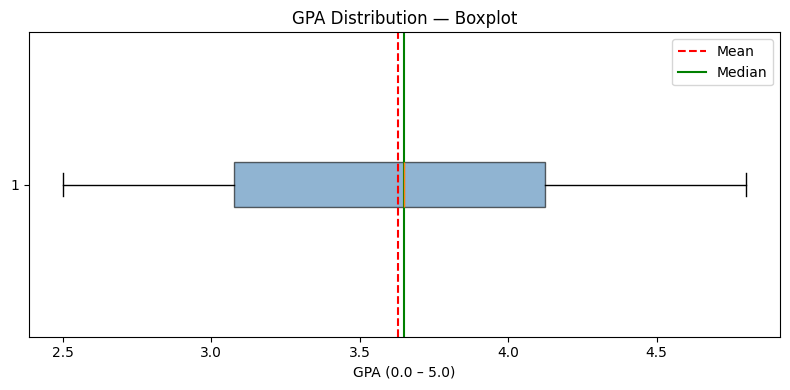

Mean: 3.63  Median: 3.65


In [13]:
# Boxplot of GPA for all students.
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(students["gpa"], vert=False, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
ax.set_title("GPA Distribution — Boxplot")
ax.set_xlabel("GPA (0.0 – 5.0)")
ax.axvline(students["gpa"].mean(), color="red", linestyle="--", label="Mean")
ax.axvline(students["gpa"].median(), color="green", linestyle="-", label="Median")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Mean: {students['gpa'].mean():.2f}  Median: {students['gpa'].median():.2f}")

### Exercise 2 — Spread per program

**Pattern: Tracker → find which group has the widest spread**

---

**Before you code**

- **Inputs:** `students` DataFrame, columns `gpa` and `program`
- **Output:** a table with min, max, std, and IQR for each program; identify the program with the widest IQR

**Decomposed steps:**

1. For each program, filter the GPA values of students in that program.
2. Compute: minimum GPA, maximum GPA, standard deviation, Q1, Q3.
3. Calculate IQR = Q3 − Q1.
4. Print all five numbers next to the program name.
5. After the loop, identify which program had the largest IQR — that is the one with the widest spread.

**Pattern:** Tracker — we keep track of the maximum IQR seen so far and which program it belongs to.

---

In [14]:
# Exercise 2: spread statistics per program.

print(f"{'Program':<15} {'Min':>5} {'Max':>5} {'Std':>6} {'IQR':>6}")
print("-" * 42)

# Tracker: keep track of the program with the widest IQR.
widest_program = None
widest_iqr = 0

for prog in sorted(students["program"].unique()):
    # Step 1: filter GPA values for this program.
    gpa_vals = students[students["program"] == prog]["gpa"]

    # Step 2: compute spread measures.
    p_min = gpa_vals.min()
    p_max = gpa_vals.max()
    p_std = gpa_vals.std()
    p_q1  = gpa_vals.quantile(0.25)
    p_q3  = gpa_vals.quantile(0.75)
    p_iqr = p_q3 - p_q1

    # Step 3: print the row.
    print(f"{prog:<15} {p_min:>5.1f} {p_max:>5.1f} {p_std:>6.2f} {p_iqr:>6.2f}")

    # Step 4: update the tracker if this is the widest IQR so far.
    if p_iqr > widest_iqr:
        widest_iqr = p_iqr
        widest_program = prog

# Round 1: prog = 'Business'    → computes spread for Business
# Round 2: prog = 'Engineering' → computes spread for Engineering
# Round 3: prog = 'Medicine'    → computes spread for Medicine

print(f"\nProgram with widest spread (IQR): {widest_program} ({widest_iqr:.2f})")
print("\nInterpretation: a wider IQR means more variation in student performance.")
print("It could indicate that the program accepts students with varying preparation.")

Program           Min   Max    Std    IQR
------------------------------------------
Business          2.5   3.7   0.40   0.33
Engineering       3.8   4.8   0.35   0.48
Medicine          2.7   4.0   0.48   0.58

Program with widest spread (IQR): Medicine (0.58)

Interpretation: a wider IQR means more variation in student performance.
It could indicate that the program accepts students with varying preparation.


---

## 🔷 Block 3 — Group Comparison

### The power of comparison

Descriptive statistics become truly useful when you compare groups.

Knowing that the average GPA is 3.65 is informative.
But knowing that **Engineering averages 4.28** while **Business averages 3.02**
tells you something actionable.

In this block we will:
1. Use `.groupby().describe()` to get full stats per group in one call
2. Use `.groupby().agg()` to compute custom statistics
3. Visualize group differences with boxplots and histograms
4. Explore the correlation between study hours and GPA

### 3.1 — Full stats per group: `.groupby().describe()`

This is the most powerful single line for group comparison.
It runs the equivalent of `.describe()` for each group at once.

In [15]:
# Full descriptive statistics for GPA, broken down by program.
gpa_by_program = students.groupby("program")["gpa"].describe()
print("GPA statistics by program:")
gpa_by_program

GPA statistics by program:


,count,mean,std,min,25%,50%,75%,max
program,,,,,,,,
Business,6.0,3.050000,0.403733,2.5,2.85,3.05,3.175,3.7
Engineering,8.0,4.287500,0.348210,3.8,4.05,4.30,4.525,4.8
Medicine,6.0,3.333333,0.476095,2.7,3.00,3.40,3.575,4.0


### 3.2 — Custom statistics: `.groupby().agg()`

When you only need a few specific statistics, `.agg()` keeps the output clean and readable.
You pass a list of function names as strings.

In [16]:
# Custom aggregation: mean, std, min, and max per program.
summary = students.groupby("program")["gpa"].agg(["mean", "std", "min", "max"])
print("Custom summary by program:")
print(summary)

# You can also aggregate multiple columns at once.
multi_summary = students.groupby("program")[["gpa", "study_hours_per_week"]].agg(["mean", "std"])
print("\nGPA and study hours by program:")
print(multi_summary)

Custom summary by program:
                 mean       std  min  max
program                                  
Business     3.050000  0.403733  2.5  3.7
Engineering  4.287500  0.348210  3.8  4.8
Medicine     3.333333  0.476095  2.7  4.0

GPA and study hours by program:
                  gpa           study_hours_per_week          
                 mean       std                 mean       std
program                                                       
Business     3.050000  0.403733            15.666667  2.732520
Engineering  4.287500  0.348210            28.250000  2.815772
Medicine     3.333333  0.476095            18.500000  2.738613


### 3.3 — Visual comparison: boxplot per group

A single boxplot per group lets you compare distributions at a glance.

> **Before running:** Based on the `.describe()` output above, which program do you expect to have the highest median GPA?

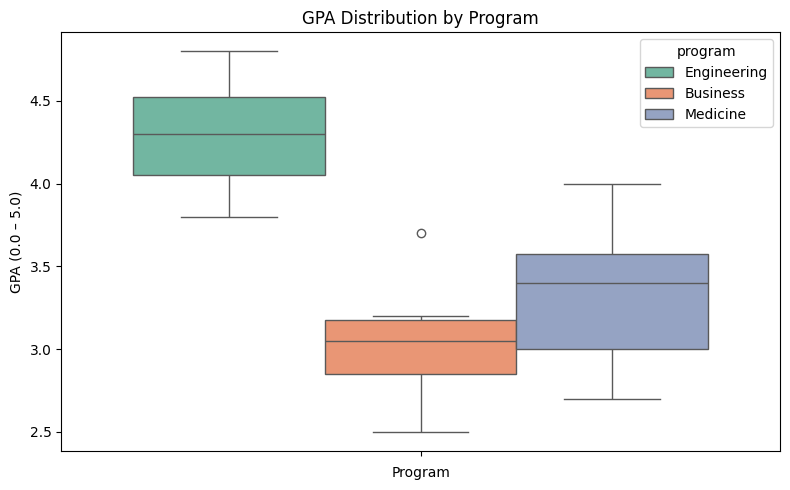

Reading the chart:
- The line inside each box = median
- The box height = IQR (middle 50%)
- The whiskers = full range (excluding outliers)


In [ ]:
# Boxplot comparing GPA distribution across all three programs.
plt.figure(figsize=(8, 5))
sns.boxplot(data=students, hue="program", y="gpa", palette="Set2") #hue=x 
plt.title("GPA Distribution by Program")
plt.xlabel("Program")
plt.ylabel("GPA (0.0 – 5.0)")
plt.tight_layout()
plt.show()
print("Reading the chart:")
print("- The line inside each box = median")
print("- The box height = IQR (middle 50%)")
print("- The whiskers = full range (excluding outliers)")

### 3.4 — Reading a histogram

A histogram shows how values are **distributed** across a range.
Each bar covers a range of values (a 'bin'); the height tells you how many data points fall in that range.

- A **symmetric, bell-shaped** distribution → mean ≈ median
- A **right-skewed** distribution (tail on the right) → mean > median
- A **left-skewed** distribution (tail on the left) → mean < median
- A **bimodal** distribution (two bumps) → the group may have two distinct sub-populations

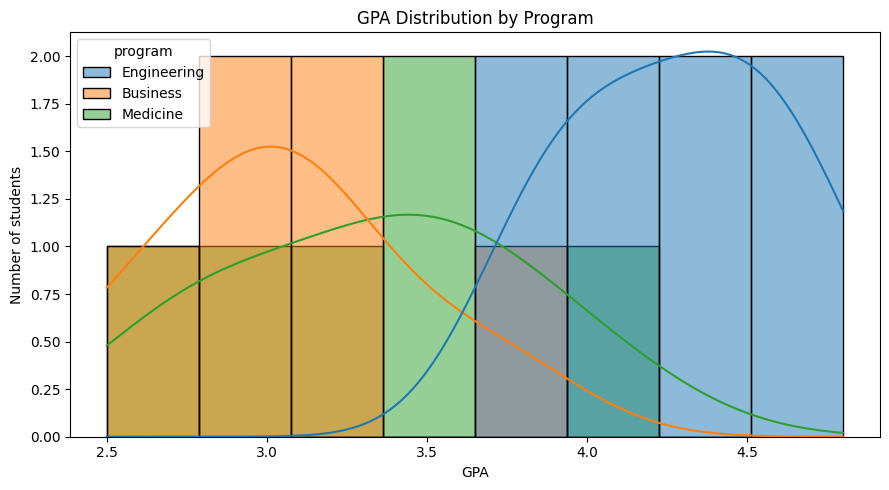

Each colored bump = one program's cluster of GPA values.
KDE line (smooth curve) = estimated shape of the distribution.


In [19]:
# Histogram of GPA for all students, colored by program.
plt.figure(figsize=(9, 5))
sns.histplot(data=students, x="gpa", hue="program", kde=True, alpha=0.5, bins=8)
plt.title("GPA Distribution by Program")
plt.xlabel("GPA")
plt.ylabel("Number of students")
plt.tight_layout()
plt.show()
print("Each colored bump = one program's cluster of GPA values.")
print("KDE line (smooth curve) = estimated shape of the distribution.")

### 3.5 — Correlation preview: study hours vs GPA

**Correlation** measures the strength and direction of the linear relationship between two numerical variables.

- **+1.0** → perfect positive correlation (one goes up, the other goes up)
- **0.0** → no linear relationship
- **−1.0** → perfect negative correlation (one goes up, the other goes down)

**Important:** correlation does **not** mean causation.
Two variables can be correlated without one causing the other.

> **Before running:** Do you expect students who study more hours to have a higher GPA? Strong or weak relationship?

Correlation (GPA vs study hours): 0.916

Strong positive correlation.


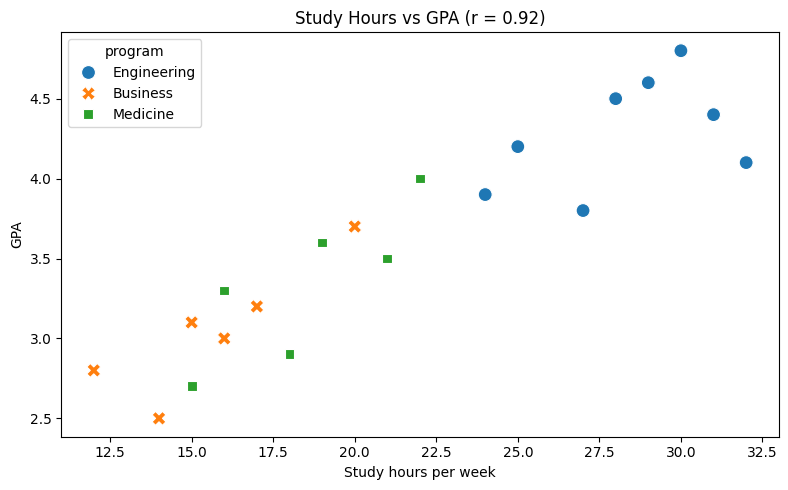

In [20]:
# Correlation between study hours and GPA.
corr_value = students["gpa"].corr(students["study_hours_per_week"])
print(f"Correlation (GPA vs study hours): {corr_value:.3f}")
print()
if corr_value > 0.7:
    print("Strong positive correlation.")
elif corr_value > 0.4:
    print("Moderate positive correlation.")
elif corr_value > 0.1:
    print("Weak positive correlation.")
else:
    print("Little to no linear correlation.")

# Scatter plot colored by program.
plt.figure(figsize=(8, 5))
sns.scatterplot(data=students, x="study_hours_per_week", y="gpa",
                hue="program", style="program", s=100)
plt.title(f"Study Hours vs GPA (r = {corr_value:.2f})")
plt.xlabel("Study hours per week")
plt.ylabel("GPA")
plt.tight_layout()
plt.show()

### Exercise 3 — Group statistics and correlation

**Pattern: Accumulator → group statistics**

---

**Before you code**

- **Inputs:** `students` DataFrame, columns `program`, `gpa`, `study_hours_per_week`
- **Output:** (1) mean GPA and mean study hours per program; (2) correlation value; (3) boxplot of study hours per program

**Decomposed steps:**

1. Group the students by program.
2. For each group, compute the mean GPA and the mean study hours per week.
3. Compute the correlation between study hours and GPA across all students.
4. Create a boxplot that shows study hours per program side by side.
5. Read the chart: does the program with the most study hours also have the highest GPA?

**Pattern:** Accumulator — computing summary numbers (mean) for each group.

---

Mean GPA and study hours per program:
             Mean GPA  Mean Study Hours
program                                
Business     3.050000         15.666667
Engineering  4.287500         28.250000
Medicine     3.333333         18.500000

Correlation (study hours vs GPA): 0.916


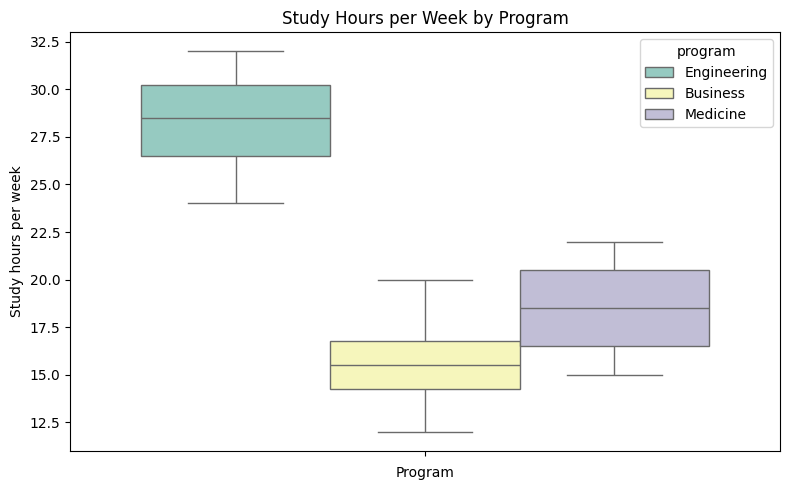


Does the program with the most study hours have the highest average GPA?
Compare the two tables above to draw your conclusion.


In [ ]:
# Exercise 3: mean GPA and study hours per program.

# Step 1: compute mean GPA and study hours per program.
group_summary = students.groupby("program")[["gpa", "study_hours_per_week"]].mean()
group_summary.columns = ["Mean GPA", "Mean Study Hours"]
print("Mean GPA and study hours per program:")
print(group_summary)

# Step 2: correlation between study hours and GPA.
r = students["gpa"].corr(students["study_hours_per_week"])
print(f"\nCorrelation (study hours vs GPA): {r:.3f}")

# Step 3: boxplot of study hours per program.
plt.figure(figsize=(8, 5))
sns.boxplot(data=students, hue="program", y="study_hours_per_week", palette="Set3") #x=hue
plt.title("Study Hours per Week by Program")
plt.xlabel("Program")
plt.ylabel("Study hours per week")
plt.tight_layout()
plt.show()
print("\nDoes the program with the most study hours have the highest average GPA?")
print("Compare the two tables above to draw your conclusion.")

---

## 🔷 Block 4 — Mini-project: Academic Performance Report

### Scenario

You are a data analyst at a Colombian university.
The academic dean has asked you to prepare a performance report comparing the three programs.

She wants to know:
1. What are the overall statistics? Are there differences between programs?
2. Who are the top students in each program? Who is at risk?
3. Do students who study more hours perform better?
4. A visual dashboard (2×2 chart grid) summarizing all findings.
5. A written conclusion she can read without looking at the code.

You will build this report step by step.

---

### Full decomposition

**PART A — Overview statistics:**
- Compute mean, median, and standard deviation of GPA for all students combined.
- Compute the same three statistics broken down by program.

**PART B — Find notable students:**
- Find the student with the highest GPA in each program.
- Find all students with a GPA below 3.0 (at risk).
- Count how many at-risk students are in each program.

**PART C — Study habits analysis:**
- Compute the average study hours per program.
- Compute the correlation between study hours and GPA.

**PART D — Visualization dashboard (2×2 grid):**
- Chart 1 (top-left): Boxplot of GPA per program.
- Chart 2 (top-right): Scatter plot of study hours vs GPA, colored by program.
- Chart 3 (bottom-left): Bar chart of average GPA per program.
- Chart 4 (bottom-right): Histogram of GPA for all students.

**PART E — Written conclusions:**
- Which program has the strongest performance?
- Is the difference meaningful or small (use std/IQR to judge)?
- Do study hours predict GPA?

In [23]:
# ── PART A: Overview statistics ─────────────────────────────────────────────

print("=" * 50)
print("PART A — Overview Statistics")
print("=" * 50)

# Overall stats for all students.
overall_mean   = students["gpa"].mean()
overall_median = students["gpa"].median()
overall_std    = students["gpa"].std()

print(f"\nAll students (n={len(students)}):")
print(f"  Mean:   {overall_mean:.2f}")
print(f"  Median: {overall_median:.2f}")
print(f"  Std:    {overall_std:.2f}")

# Stats per program.
print("\nBy program:")
program_stats = students.groupby("program")["gpa"].agg(["mean", "median", "std"])
print(program_stats)

PART A — Overview Statistics

All students (n=20):
  Mean:   3.63
  Median: 3.65
  Std:    0.68

By program:
                 mean  median       std
program                                
Business     3.050000    3.05  0.403733
Engineering  4.287500    4.30  0.348210
Medicine     3.333333    3.40  0.476095


In [27]:
# ── PART B: Notable students ─────────────────────────────────────────────────

print("=" * 50)
print("PART B — Notable Students")
print("=" * 50)

# Top student per program.
print("\nTop student per program:")
for prog in sorted(students["program"].unique()):
    subset = students[students["program"] == prog]
    top_idx = subset["gpa"].idxmax()         # Index of the row with the highest GPA.
    top_student = subset.loc[top_idx]
    print(f"  {prog:<15}: {top_student['name']} (GPA {top_student['gpa']:.1f})")

# Students at risk: GPA below 3.0.
at_risk = students[students["gpa"] < 3.0]
print(f"\nStudents at risk (GPA < 3.0): {len(at_risk)}")
print(at_risk[["name", "program", "gpa"]].to_string(index=False))

# At-risk count per program.
print("\nAt-risk students per program:")
print(at_risk["program"].value_counts())

PART B — Notable Students

Top student per program:
  Business       : Isabella (GPA 3.7)
  Engineering    : Camila (GPA 4.8)
  Medicine       : Ana (GPA 4.0)

Students at risk (GPA < 3.0): 4
   name  program  gpa
 Andrés Medicine  2.9
 Miguel Business  2.8
 Carlos Business  2.5
Esteban Medicine  2.7

At-risk students per program:
program
Medicine    2
Business    2
Name: count, dtype: int64


In [28]:
# ── PART C: Study habits analysis ────────────────────────────────────────────

print("=" * 50)
print("PART C — Study Habits Analysis")
print("=" * 50)

# Average study hours per program.
avg_hours = students.groupby("program")["study_hours_per_week"].mean()
print("\nAverage study hours per week by program:")
print(avg_hours)

# Correlation between study hours and GPA.
r = students["gpa"].corr(students["study_hours_per_week"])
print(f"\nCorrelation (study hours vs GPA): {r:.3f}")
print("Interpretation: values close to +1 mean more hours → higher GPA.")

PART C — Study Habits Analysis

Average study hours per week by program:
program
Business       15.666667
Engineering    28.250000
Medicine       18.500000
Name: study_hours_per_week, dtype: float64

Correlation (study hours vs GPA): 0.916
Interpretation: values close to +1 mean more hours → higher GPA.


C:\Users\julip\AppData\Local\Temp\ipykernel_5672\1179372207.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=students, x="program", y="gpa", palette="Set2", ax=axes[0, 0])


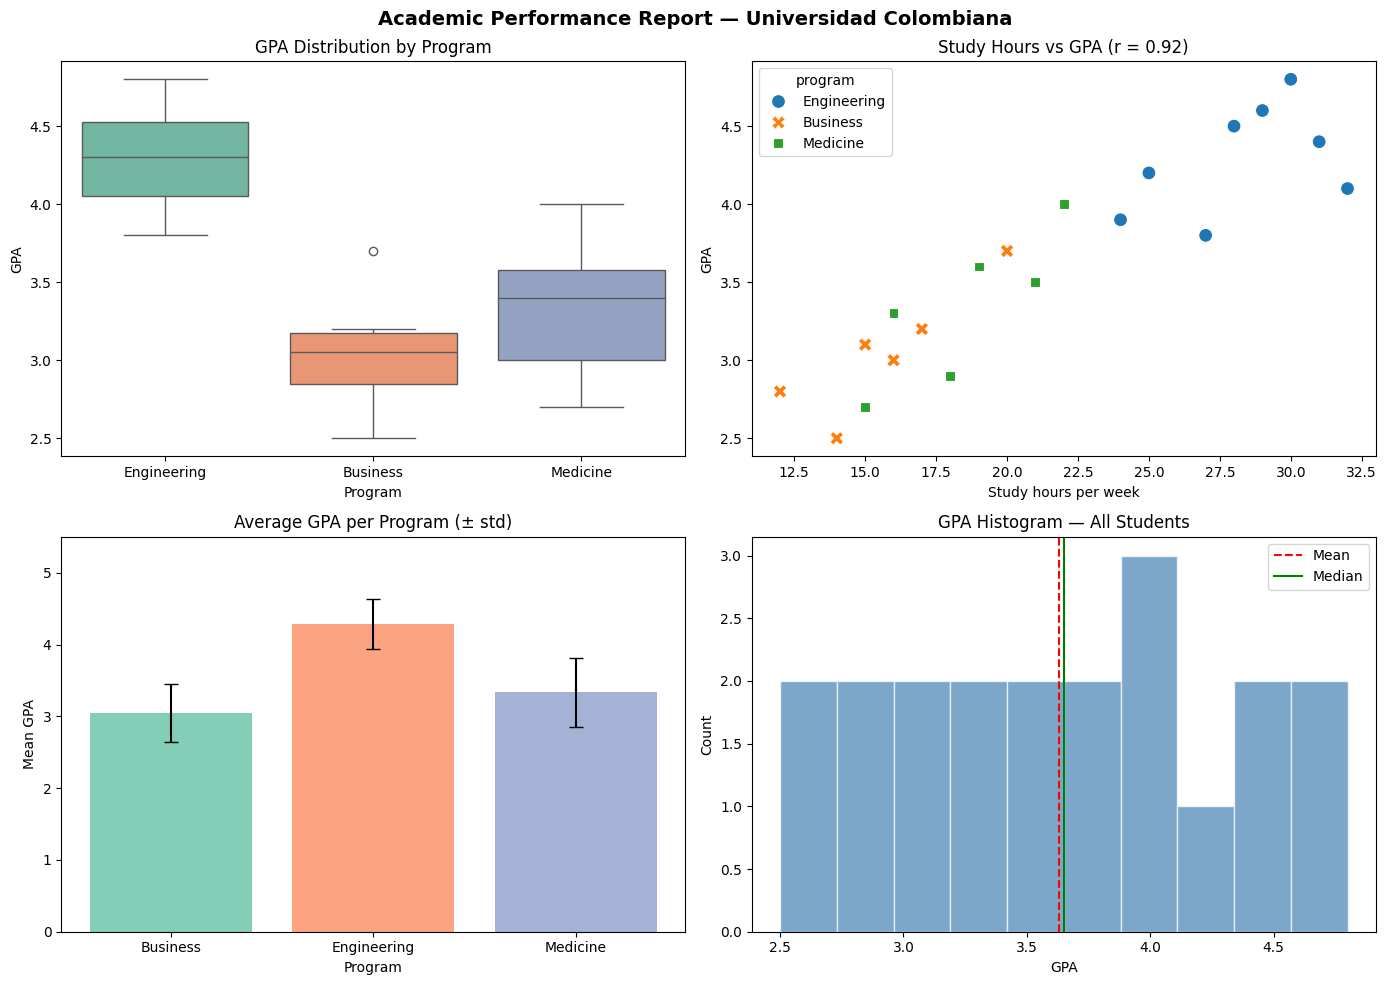

In [29]:
# ── PART D: Visualization dashboard (2×2 grid) ───────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Academic Performance Report — Universidad Colombiana", fontsize=14, fontweight="bold")

# Chart 1 (top-left): Boxplot of GPA per program.
sns.boxplot(data=students, x="program", y="gpa", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("GPA Distribution by Program")
axes[0, 0].set_xlabel("Program")
axes[0, 0].set_ylabel("GPA")

# Chart 2 (top-right): Scatter of study hours vs GPA.
sns.scatterplot(data=students, x="study_hours_per_week", y="gpa",
                hue="program", style="program", s=100, ax=axes[0, 1])
axes[0, 1].set_title(f"Study Hours vs GPA (r = {r:.2f})")
axes[0, 1].set_xlabel("Study hours per week")
axes[0, 1].set_ylabel("GPA")

# Chart 3 (bottom-left): Bar chart of average GPA per program.
avg_gpa = students.groupby("program")["gpa"].mean().reset_index()
std_gpa = students.groupby("program")["gpa"].std().reset_index()
axes[1, 0].bar(avg_gpa["program"], avg_gpa["gpa"],
               yerr=std_gpa["gpa"], capsize=5,
               color=["#66c2a5", "#fc8d62", "#8da0cb"], alpha=0.8)
axes[1, 0].set_title("Average GPA per Program (± std)")
axes[1, 0].set_xlabel("Program")
axes[1, 0].set_ylabel("Mean GPA")
axes[1, 0].set_ylim(0, 5.5)

# Chart 4 (bottom-right): Histogram of GPA for all students.
axes[1, 1].hist(students["gpa"], bins=10, color="steelblue", alpha=0.7, edgecolor="white")
axes[1, 1].axvline(students["gpa"].mean(), color="red", linestyle="--", label="Mean")
axes[1, 1].axvline(students["gpa"].median(), color="green", linestyle="-", label="Median")
axes[1, 1].set_title("GPA Histogram — All Students")
axes[1, 1].set_xlabel("GPA")
axes[1, 1].set_ylabel("Count")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### PART E — Written Conclusions

*(Fill in the blanks based on the numbers you computed above.)*

---

**1. Overall performance**

The class average GPA is approximately is 3.63  with a median of 3.65.
The mean and median are close by 0.02, suggesting the distribution is roughly symmetric

**2. Program comparison**

The program with the highest average GPA is engineering (mean = 4.29).
The program with the lowest average GPA is bussiness (mean = 3.05).
The difference between them is 1.24 GPA points.
Given a standard deviation of roughly (0.68)  this difference is small.

**3. At-risk students**

There are 4  students with a GPA below 3.0.
They are concentrated in bussiness and medicine programs

**4. Study habits**

The program that studies the most hours per week on average is engineering
The correlation between study hours and GPA is r =0.92
This suggests a strong positive relationship.
However, we cannot conclude that studying more guarentee us a higher GPA
(correlation ≠ causation — other factors like prior knowledge, study quality, etc. may play a role).

---

## 🟣 Optional · pytest — Validating Statistical Results

> Skip this section if pytest was not activated for your course.

### Why test statistical results?

When you clean or aggregate data, bugs can produce numbers that look plausible but are wrong.
For example:
- A GPA of 6.2 would silently pass without a test.
- A standard deviation of 0.0 means all students have the same GPA — suspicious!

By writing assertions on your results, you catch these issues automatically.

These tests use the same `assert` statement you learned in M4.

In [30]:
# Inline assertions — run these directly in the notebook.

# Test 1: mean GPA must be in a reasonable range.
avg = students["gpa"].mean()
assert 2.5 <= avg and avg <= 4.5, f"Unexpected average GPA: {avg}"
print(f"PASS — mean GPA is {avg:.2f} (within 2.5–4.5)")

# Test 2: standard deviation must be positive.
std = students["gpa"].std()
assert std > 0, "Standard deviation must be positive — all GPAs are identical!"
print(f"PASS — std is {std:.2f} (positive)")

# Test 3: no GPA can exceed the 0.0–5.0 scale.
assert (students["gpa"] <= 5.0).all(), "At least one GPA exceeds 5.0!"
assert (students["gpa"] >= 0.0).all(), "At least one GPA is negative!"
print("PASS — all GPAs are within the valid 0.0–5.0 scale")

# Test 4: each program must have at least one student.
program_counts = students["program"].value_counts()
assert (program_counts > 0).all(), "At least one program has no students!"
print(f"PASS — all {len(program_counts)} programs have students")

# Test 5: median must be between min and max.
median = students["gpa"].median()
assert students["gpa"].min() <= median <= students["gpa"].max(), "Median out of range!"
print(f"PASS — median ({median:.2f}) is between min and max")

print("\nAll assertions passed.")

PASS — mean GPA is 3.63 (within 2.5–4.5)
PASS — std is 0.68 (positive)
PASS — all GPAs are within the valid 0.0–5.0 scale
PASS — all 3 programs have students
PASS — median (3.65) is between min and max

All assertions passed.


### Writing a pytest file

You can save these assertions as a proper test file so pytest can run them automatically.
Create `test_homework_module9.py` with the structure below.

Run it from the terminal with:
```
pytest test_homework_module9.py -v
```

In [ ]:
# Example structure for test_homework_module9.py
# (This is a preview — the actual file is part of the homework.)

example_test_code = '''
import pandas as pd
import numpy as np

# Import the functions from your homework file.
from homework_module9 import compute_category_stats, find_highest_expense_month

expenses = pd.DataFrame({
    "month": ["Jan", "Feb", "Mar"],
    "food":      [850000, 820000, 900000],
    "transport": [320000, 310000, 330000],
})

def test_mean_is_positive():
    stats = compute_category_stats(expenses)
    assert stats["food"]["mean"] > 0

def test_highest_month_is_valid():
    result = find_highest_expense_month(expenses)
    assert result in expenses["month"].values
'''

print(example_test_code)

---

## 📝 Homework — Module 9

### Dataset: Monthly family expenses

A Colombian family tracks their expenses across 5 categories for all 12 months of the year.

---

### Tasks

1. **Central tendency:** Compute mean, median, and standard deviation for each expense category.
2. **Highest variation:** Which category has the highest variation? Use std or IQR to justify your answer.
3. **Busiest month:** Which month had the highest *total* expenses (all categories combined)?
4. **Visualization 1:** Line chart of food expenses over the 12 months.
5. **Visualization 2:** Boxplot comparing all 5 categories side by side.

---

*Delivery: bring `homework_module9.py` to the next session. It must run without errors.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Monthly expenses of a Colombian family for 12 months across 5 categories.
expenses = pd.DataFrame({
    "month":     ["Jan","Feb","Mar","Apr","May","Jun",
                  "Jul","Aug","Sep","Oct","Nov","Dec"],
    "food":      [850000,820000,900000,780000,860000,920000,
                  870000,810000,840000,880000,950000,1100000],
    "transport": [320000,310000,330000,300000,315000,325000,
                  320000,305000,310000,320000,330000,350000],
    "utilities": [280000,260000,275000,290000,270000,265000,
                  280000,295000,285000,275000,290000,310000],
    "education": [500000,500000,500000,500000,500000,500000,
                  0,0,500000,500000,500000,500000],
    "leisure":   [200000,180000,250000,150000,220000,350000,
                  400000,380000,210000,190000,320000,500000]
})


# ── Task 1: central tendency per category ─────────────────────────────────────
# Before you code:
#   Inputs: expenses DataFrame, all numeric columns
#   Output: a table showing mean, median, std for each of the 5 categories
#   Steps:
#     1. Select only the numeric columns (food, transport, utilities, education, leisure).
#     2. Compute mean, median, and std for each column.
#     3. Print the result.
#   Pattern: Accumulator (summarizing each column)

categories = ["food", "transport", "utilities", "education", "leisure"]
# TODO: compute and print mean, median, std for each category.
pass


# ── Task 2: highest variation ─────────────────────────────────────────────────
# Before you code:
#   Inputs: expenses DataFrame, the 5 category columns
#   Output: the name of the category with the highest std or IQR, and its value
#   Steps:
#     1. Compute std (or IQR) for each category.
#     2. Find which category has the maximum std.
#     3. Print that category name and its std value.
#   Pattern: Tracker (finding the maximum)

# TODO: find and print the category with the highest variation.
pass


# ── Task 3: month with highest total expenses ─────────────────────────────────
# Before you code:
#   Inputs: expenses DataFrame
#   Output: the name of the month where the sum of all 5 categories is highest
#   Steps:
#     1. For each row (month), add up all five category values.
#     2. Store the totals in a new column called 'total'.
#     3. Find the row where 'total' is maximum.
#     4. Print the month name and the total amount.
#   Pattern: Tracker (finding the maximum total)

# TODO: compute total expenses per month and find the highest month.
pass


# ── Task 4: line chart of food expenses ──────────────────────────────────────
# TODO: plot a line chart of food expenses over the 12 months.
#       Add title, x-label, y-label.
pass


# ── Task 5: boxplot comparing all categories ──────────────────────────────────
# Hint: to make a side-by-side boxplot, you need to reshape the data first.
# expenses_melted = expenses[categories].melt(var_name="category", value_name="amount")
# Then use sns.boxplot(data=expenses_melted, x="category", y="amount")
# TODO: create the boxplot with proper title and axis labels.
pass

---

## 📋 Module 9 Summary

| Concept | Syntax | Key point |
|---------|--------|-----------|
| Mean | `df["col"].mean()` | Sensitive to outliers |
| Median | `df["col"].median()` | Robust to outliers |
| Mode | `df["col"].mode()[0]` | Most frequent value; returns a Series |
| Standard deviation | `df["col"].std()` | Spread in original units |
| Variance | `df["col"].var()` | Squared units — less intuitive |
| Range | `df["col"].max() - df["col"].min()` | Simplest spread; sensitive to extremes |
| IQR | `q3 - q1` | Middle 50%; outlier-resistant |
| Quartiles | `df["col"].quantile([.25, .5, .75])` | Three cut points of sorted data |
| Full summary | `df.groupby("col").describe()` | All stats per group in one call |
| Custom summary | `df.groupby("col").agg(["mean","std"])` | Select which stats to compute |
| Correlation | `col1.corr(col2)` | −1 to +1; measures linear relationship |
| Boxplot | `sns.boxplot(data=df, x=..., y=...)` | Shows median, IQR, and outliers |
| Histogram | `sns.histplot(data=df, x=..., hue=...)` | Shows shape of distribution |

---

**Next module:** Exploratory Data Analysis — from data to insights 🔍